# Geography and Mathematics Subject Diversity

This notebook studies the interaction between **geography** and **MSC subject areas** using the state–year–subject dissertation-count table.

The main questions are:

1. For each subject, how geographically dispersed are its dissertations across states?
2. For each state, how diverse is its subject composition?
3. Are state and subject becoming more or less strongly associated over time?
4. Which subjects and states have become more diversified or more concentrated?

The main period is **1960–2025**. The year 2025 is retained as the most recent observation, but it should be interpreted as provisional if the MGP data are incomplete.

Entropy is calculated in two directions:

$$
H(\mathrm{State}\mid \mathrm{Subject})
$$

and

$$
H(\mathrm{Subject}\mid \mathrm{State}).
$$

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)

## 1. Load and clean the aggregated geography data

The expected columns are:

```text
year
state
subject
num_dissertations
```

Each row contains the number of dissertations for one state, year, and MSC subject.

In [2]:
DATA_CANDIDATES = [
    Path(
        "../../data/processed/"
        "dissertation_counts_by_state_year_subject.csv"
    ),
    Path(
        "../data/processed/"
        "dissertation_counts_by_state_year_subject.csv"
    ),
    Path(
        "data/processed/"
        "dissertation_counts_by_state_year_subject.csv"
    ),
]

DATA_PATH = next(
    (path for path in DATA_CANDIDATES if path.exists()),
    DATA_CANDIDATES[0],
)

nodes = pd.read_csv(DATA_PATH, low_memory=False)

YEAR_START = 1960
YEAR_END = 2025
YEARS = np.arange(YEAR_START, YEAR_END + 1)

nodes["year"] = pd.to_numeric(
    nodes["year"],
    errors="coerce",
)
nodes["num_dissertations"] = pd.to_numeric(
    nodes["num_dissertations"],
    errors="coerce",
)

nodes = nodes.dropna(
    subset=[
        "year",
        "state",
        "subject",
        "num_dissertations",
    ]
).copy()

nodes["year"] = nodes["year"].astype(int)
nodes["num_dissertations"] = (
    nodes["num_dissertations"].astype(float)
)

nodes = nodes[
    nodes["year"].between(YEAR_START, YEAR_END)
    & nodes["num_dissertations"].gt(0)
].copy()

# Separate the top-level MSC code from the subject name.
subject_parts = nodes["subject"].str.extract(
    r"^\s*(\d{2})\s*[—-]\s*(.*)$"
)

nodes["subject_code"] = pd.to_numeric(
    subject_parts[0],
    errors="coerce",
)
nodes["subject_name"] = subject_parts[1].fillna(
    nodes["subject"]
).str.strip()

nodes = nodes.dropna(subset=["subject_code"]).copy()
nodes["subject_code"] = nodes["subject_code"].astype(int)

nodes["basket"] = np.where(
    nodes["subject_code"].le(60),
    "Pure",
    "Applied",
)

# Combine accidental duplicate state–year–subject rows.
nodes = (
    nodes.groupby(
        [
            "year",
            "state",
            "subject_code",
            "subject_name",
            "basket",
        ],
        as_index=False,
    )["num_dissertations"]
    .sum()
)

subject_name_map = (
    nodes.groupby("subject_code")["subject_name"]
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)

def subject_label(code):
    code = int(code)
    return f"{code}: {subject_name_map.get(code, '')}".rstrip(": ")


print("Data path:", DATA_PATH)
print("Rows:", f"{len(nodes):,}")
print("States/geographic units:", nodes["state"].nunique())
print("Subjects:", nodes["subject_code"].nunique())
print("Years:", nodes["year"].min(), "to", nodes["year"].max())

Data path: ../../data/processed/dissertation_counts_by_state_year_subject.csv
Rows: 24,499
States/geographic units: 51
Subjects: 63
Years: 1960 to 2025


## 2. Coverage over time

Entropy estimates are less stable when only a few dissertations are observed. The coverage plots show the annual number of dissertations, active states, and active subjects.

Later heatmaps use minimum-count thresholds to avoid interpreting very small state–year or subject–year samples as meaningful diversity estimates.

In [3]:
coverage = (
    nodes.groupby("year")
    .agg(
        dissertations=(
            "num_dissertations",
            "sum",
        ),
        active_states=(
            "state",
            "nunique",
        ),
        active_subjects=(
            "subject_code",
            "nunique",
        ),
    )
    .reindex(YEARS)
)

display(coverage.tail(10))

,dissertations,active_states,active_subjects
year,,,
2016,2397.0,48,60
2017,2341.0,50,56
2018,2267.0,50,59
2019,2153.0,49,61
2020,1958.0,49,57
2021,1805.0,47,56
2022,1623.0,47,59
2023,1526.0,48,55
2024,1284.0,45,59


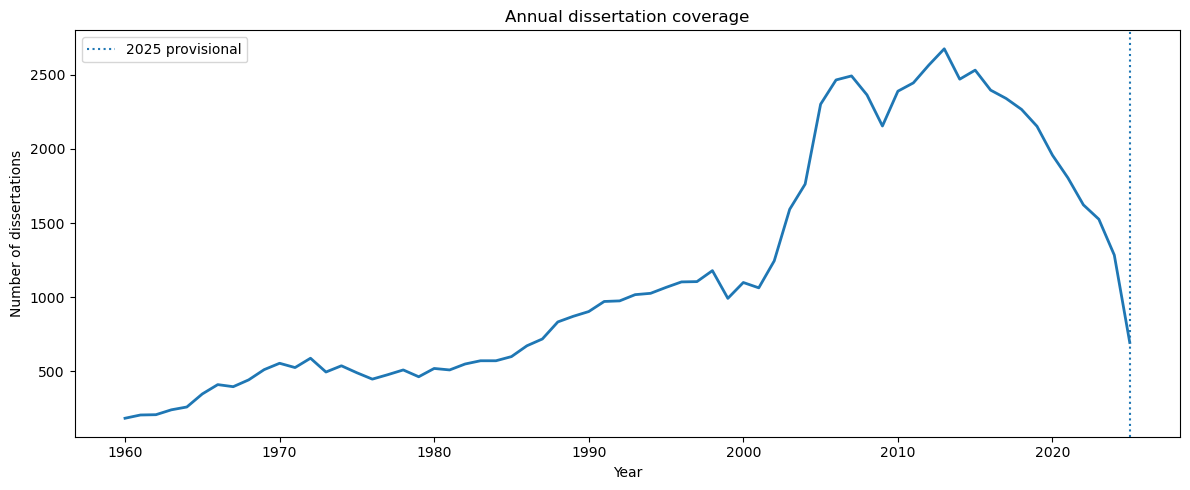

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(
    coverage.index,
    coverage["dissertations"],
    linewidth=2,
)
plt.axvline(
    2025,
    linestyle=":",
    linewidth=1.5,
    label="2025 provisional",
)
plt.xlabel("Year")
plt.ylabel("Number of dissertations")
plt.title("Annual dissertation coverage")
plt.legend()
plt.tight_layout()
plt.show()

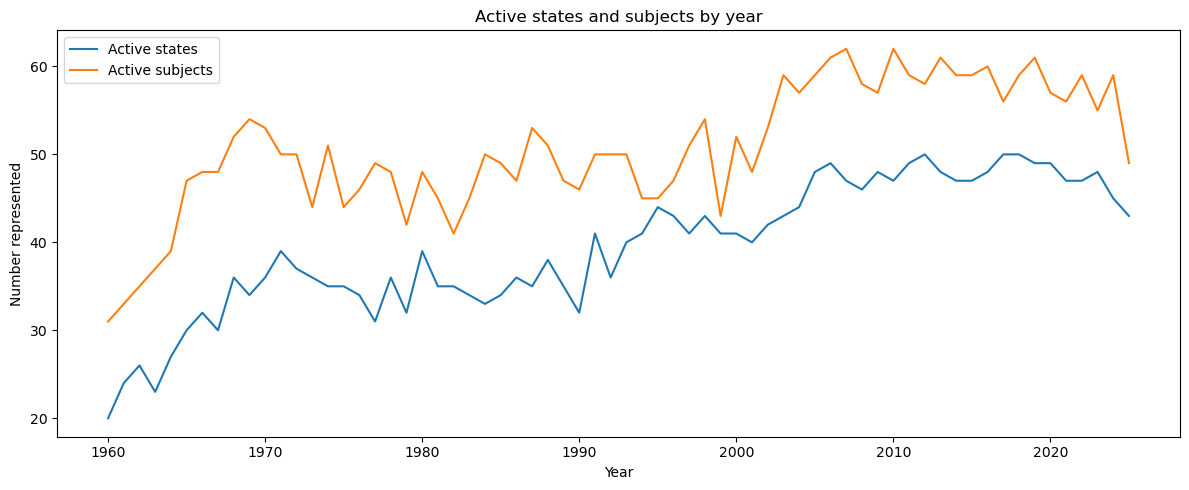

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(
    coverage.index,
    coverage["active_states"],
    label="Active states",
)
plt.plot(
    coverage.index,
    coverage["active_subjects"],
    label="Active subjects",
)
plt.xlabel("Year")
plt.ylabel("Number represented")
plt.title("Active states and subjects by year")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Entropy definitions

For a fixed subject $s$ and year $t$, let

$$
p_{g\mid s,t}
=
\frac{n_{g,s,t}}
{\sum_{g'}n_{g',s,t}},
$$

where $g$ denotes state. The geographic entropy of subject $s$ is

$$
H_{\mathrm{state}\mid s,t}
=
-\sum_g
p_{g\mid s,t}
\log p_{g\mid s,t}.
$$

For a fixed state $g$ and year $t$, let

$$
p_{s\mid g,t}
=
\frac{n_{g,s,t}}
{\sum_{s'}n_{g,s',t}}.
$$

The subject entropy of state $g$ is

$$
H_{\mathrm{subject}\mid g,t}
=
-\sum_s
p_{s\mid g,t}
\log p_{s\mid g,t}.
$$

To compare values over time, the entropies are normalized using the full observed universes:

$$
H_{\mathrm{state}\mid s,t}^{\mathrm{norm}}
=
\frac{H_{\mathrm{state}\mid s,t}}
{\log G},
$$

$$
H_{\mathrm{subject}\mid g,t}^{\mathrm{norm}}
=
\frac{H_{\mathrm{subject}\mid g,t}}
{\log M},
$$

where $G$ is the number of geographic units and $M$ is the number of MSC subjects in the analysis.

The normalized values lie between 0 and 1:

- values near 0 indicate concentration;
- values near 1 indicate a more even distribution.

The effective numbers are

$$
N_{\mathrm{states}}^{\mathrm{eff}}
=
\exp(H_{\mathrm{state}\mid s,t}),
$$

and

$$
N_{\mathrm{subjects}}^{\mathrm{eff}}
=
\exp(H_{\mathrm{subject}\mid g,t}).
$$

In [6]:
NUMBER_OF_STATES = nodes["state"].nunique()
NUMBER_OF_SUBJECTS = nodes["subject_code"].nunique()

MIN_SUBJECT_YEAR_COUNT = 20
MIN_STATE_YEAR_COUNT = 20


def grouped_entropy(
    data,
    group_columns,
    category_column,
    universe_size,
):
    grouped_counts = (
        data.groupby(
            list(group_columns) + [category_column],
            as_index=False,
        )["num_dissertations"]
        .sum()
    )

    grouped_counts["group_total"] = (
        grouped_counts.groupby(
            list(group_columns)
        )["num_dissertations"]
        .transform("sum")
    )

    grouped_counts["probability"] = (
        grouped_counts["num_dissertations"]
        / grouped_counts["group_total"]
    )

    grouped_counts["entropy_term"] = -(
        grouped_counts["probability"]
        * np.log(grouped_counts["probability"])
    )

    result = (
        grouped_counts.groupby(
            list(group_columns),
            as_index=False,
        )
        .agg(
            entropy=("entropy_term", "sum"),
            total_count=("group_total", "first"),
            active_categories=(
                category_column,
                "nunique",
            ),
        )
    )

    result["normalized_entropy"] = (
        result["entropy"] / np.log(universe_size)
    )
    result["effective_number"] = np.exp(
        result["entropy"]
    )

    return result

## 4. Geographic diversity of each subject

This section measures how evenly each subject is distributed across states.

A high value means that dissertations in the subject are spread across many states. A low value means that the subject is geographically concentrated.

In [7]:
subject_geography_entropy = grouped_entropy(
    data=nodes,
    group_columns=[
        "year",
        "subject_code",
        "subject_name",
        "basket",
    ],
    category_column="state",
    universe_size=NUMBER_OF_STATES,
)

subject_geography_entropy["subject_label"] = (
    subject_geography_entropy["subject_code"]
    .map(subject_label)
)

subject_geography_entropy["reliable"] = (
    subject_geography_entropy["total_count"]
    .ge(MIN_SUBJECT_YEAR_COUNT)
)

display(subject_geography_entropy.head())

,year,subject_code,subject_name,basket,entropy,total_count,active_categories,normalized_entropy,effective_number,subject_label,reliable
0,1960,0,General,Pure,0.000000,1.0,1,0.000000,1.0,0: General,False
1,1960,1,History and biography,Pure,1.098612,3.0,3,0.279415,3.0,1: History and biography,False
2,1960,3,Mathematical logic and foundations,Pure,1.098612,3.0,3,0.279415,3.0,3: Mathematical logic and foundations,False
3,1960,14,Algebraic geometry,Pure,0.000000,1.0,1,0.000000,1.0,14: Algebraic geometry,False
4,1960,18,"Category theory, homological algebra",Pure,0.693147,2.0,2,0.176291,2.0,"18: Category theory, homological algebra",False


### 4.1 Aggregate geographic diversity

The weighted average below is the normalized conditional entropy

$$
\frac{H(\mathrm{State}\mid \mathrm{Subject})}
{\log G}.
$$

Each subject receives weight proportional to its number of dissertations in that year. Pure and applied subjects are also shown separately.

In [8]:
def weighted_yearly_entropy(
    entropy_table,
    grouping_column=None,
):
    group_columns = ["year"]

    if grouping_column is not None:
        group_columns.append(grouping_column)

    table = entropy_table.copy()
    table["weighted_entropy"] = (
        table["entropy"]
        * table["total_count"]
    )
    table["weighted_normalized_entropy"] = (
        table["normalized_entropy"]
        * table["total_count"]
    )

    summary = (
        table.groupby(
            group_columns,
            as_index=False,
        )
        .agg(
            total_count=("total_count", "sum"),
            weighted_entropy=(
                "weighted_entropy",
                "sum",
            ),
            weighted_normalized_entropy=(
                "weighted_normalized_entropy",
                "sum",
            ),
        )
    )

    summary["conditional_entropy"] = (
        summary["weighted_entropy"]
        / summary["total_count"]
    )
    summary["normalized_conditional_entropy"] = (
        summary["weighted_normalized_entropy"]
        / summary["total_count"]
    )
    summary["effective_number"] = np.exp(
        summary["conditional_entropy"]
    )

    return summary


subject_geo_all = weighted_yearly_entropy(
    subject_geography_entropy
)
subject_geo_all["basket"] = "All mathematics"

subject_geo_by_basket = weighted_yearly_entropy(
    subject_geography_entropy,
    grouping_column="basket",
)

subject_geo_summary = pd.concat(
    [
        subject_geo_by_basket,
        subject_geo_all,
    ],
    ignore_index=True,
)

subject_geo_summary["smoothed_entropy"] = (
    subject_geo_summary
    .sort_values("year")
    .groupby("basket")[
        "normalized_conditional_entropy"
    ]
    .transform(
        lambda x: x.rolling(
            5,
            center=True,
            min_periods=1,
        ).mean()
    )
)

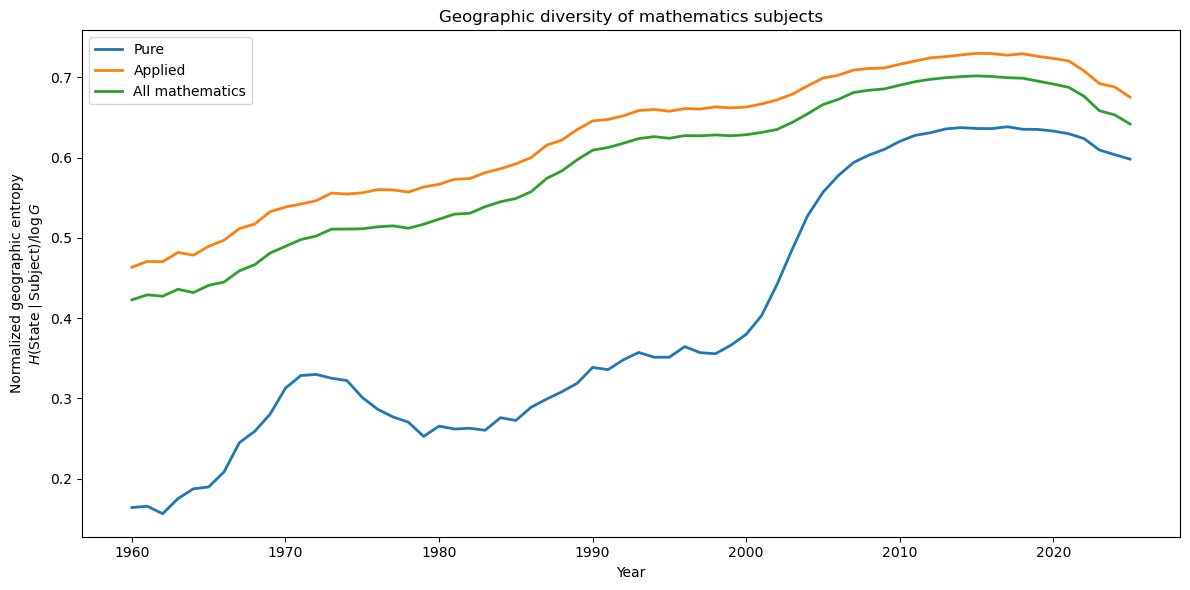

In [9]:
plt.figure(figsize=(12, 6))

for basket in ["Pure", "Applied", "All mathematics"]:
    plot_data = subject_geo_summary[
        subject_geo_summary["basket"].eq(basket)
    ].sort_values("year")

    plt.plot(
        plot_data["year"],
        plot_data["smoothed_entropy"],
        label=basket,
        linewidth=2,
    )

plt.xlabel("Year")
plt.ylabel(
    "Normalized geographic entropy\n"
    "$H(\\mathrm{State}\\mid\\mathrm{Subject})/\\log G$"
)
plt.title(
    "Geographic diversity of mathematics subjects"
)
plt.legend()
plt.tight_layout()
plt.show()

### 4.2 Annual entropy heatmap for all subjects

Cells are blank when a subject has fewer than `MIN_SUBJECT_YEAR_COUNT` dissertations in that year. This prevents extremely small samples from appearing as meaningful concentration.

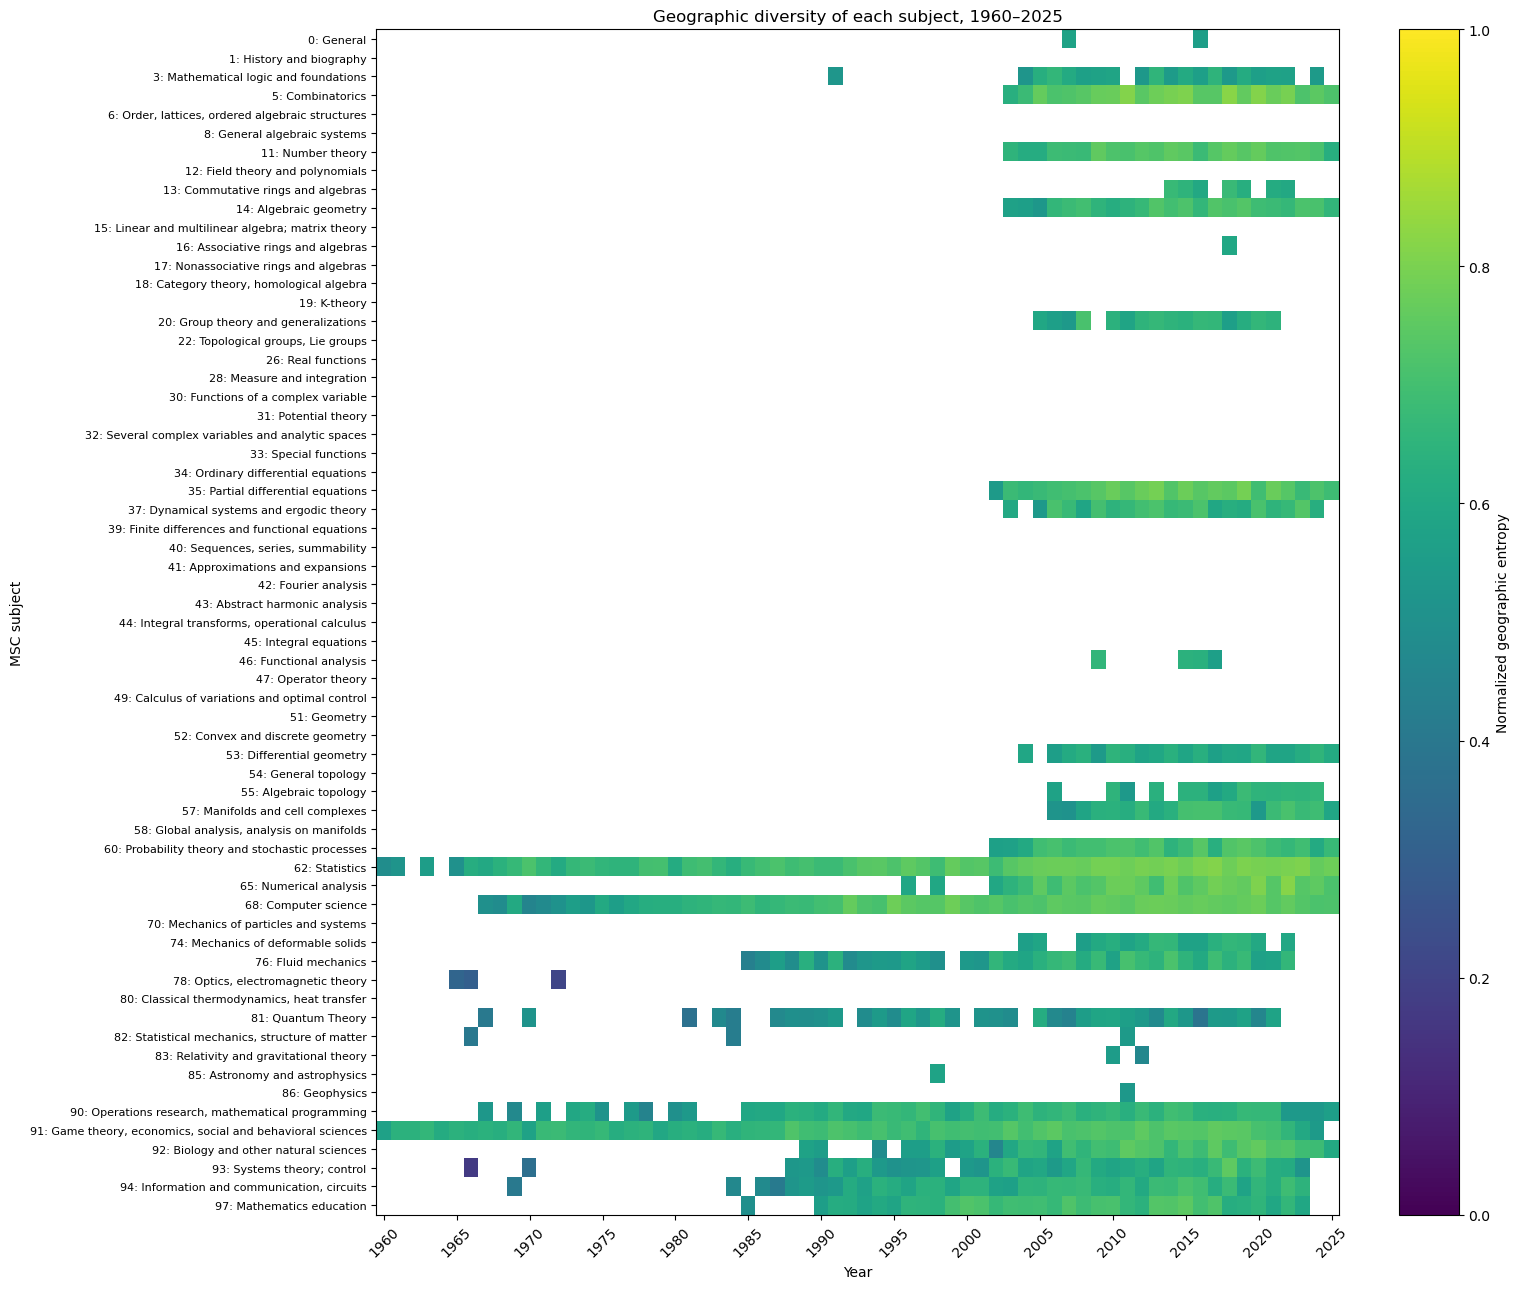

In [10]:
subject_heatmap_data = (
    subject_geography_entropy[
        subject_geography_entropy["reliable"]
    ]
    .pivot(
        index="subject_code",
        columns="year",
        values="normalized_entropy",
    )
    .reindex(
        index=sorted(
            subject_geography_entropy[
                "subject_code"
            ].unique()
        ),
        columns=YEARS,
    )
)

plt.figure(figsize=(16, 13))
image = plt.imshow(
    subject_heatmap_data.to_numpy(dtype=float),
    aspect="auto",
    vmin=0,
    vmax=1,
    interpolation="nearest",
)

plt.colorbar(
    image,
    label="Normalized geographic entropy",
)

year_tick_positions = np.arange(
    0,
    len(YEARS),
    5,
)
plt.xticks(
    year_tick_positions,
    YEARS[year_tick_positions],
    rotation=45,
)

plt.yticks(
    np.arange(subject_heatmap_data.shape[0]),
    [
        subject_label(code)
        for code in subject_heatmap_data.index
    ],
    fontsize=8,
)

plt.xlabel("Year")
plt.ylabel("MSC subject")
plt.title(
    "Geographic diversity of each subject, "
    "1960–2025"
)
plt.tight_layout()
plt.show()

### 4.3 Long-run changes in subject geographic diversity

To obtain more stable comparisons, counts are pooled over two broad periods:

```text
Early period:  1960–1979
Recent period: 2005–2025
```

The table reports subjects with the largest increases and decreases in normalized geographic entropy. Subjects must have at least 100 dissertations in each period.

In [11]:
def pooled_subject_geography_entropy(
    data,
    start_year,
    end_year,
):
    pooled = (
        data[
            data["year"].between(
                start_year,
                end_year,
            )
        ]
        .groupby(
            [
                "subject_code",
                "subject_name",
                "basket",
                "state",
            ],
            as_index=False,
        )["num_dissertations"]
        .sum()
    )

    pooled["year"] = f"{start_year}-{end_year}"

    return grouped_entropy(
        data=pooled,
        group_columns=[
            "year",
            "subject_code",
            "subject_name",
            "basket",
        ],
        category_column="state",
        universe_size=NUMBER_OF_STATES,
    )


subject_geo_early = pooled_subject_geography_entropy(
    nodes,
    1960,
    1979,
).rename(
    columns={
        "normalized_entropy": "early_entropy",
        "total_count": "early_count",
    }
)

subject_geo_recent = pooled_subject_geography_entropy(
    nodes,
    2005,
    2025,
).rename(
    columns={
        "normalized_entropy": "recent_entropy",
        "total_count": "recent_count",
    }
)

subject_geo_change = subject_geo_early[
    [
        "subject_code",
        "subject_name",
        "basket",
        "early_entropy",
        "early_count",
    ]
].merge(
    subject_geo_recent[
        [
            "subject_code",
            "recent_entropy",
            "recent_count",
        ]
    ],
    on="subject_code",
    how="inner",
)

subject_geo_change = subject_geo_change[
    subject_geo_change["early_count"].ge(100)
    & subject_geo_change["recent_count"].ge(100)
].copy()

subject_geo_change["entropy_change"] = (
    subject_geo_change["recent_entropy"]
    - subject_geo_change["early_entropy"]
)

subject_geo_change["subject_label"] = (
    subject_geo_change["subject_code"]
    .map(subject_label)
)

subject_geo_change_ranked = pd.concat(
    [
        subject_geo_change.nlargest(
            10,
            "entropy_change",
        ).assign(direction="More geographically dispersed"),
        subject_geo_change.nsmallest(
            10,
            "entropy_change",
        ).assign(direction="More geographically concentrated"),
    ],
    ignore_index=True,
)

display(
    subject_geo_change_ranked[
        [
            "direction",
            "subject_label",
            "basket",
            "early_entropy",
            "recent_entropy",
            "entropy_change",
            "early_count",
            "recent_count",
        ]
    ].round(3)
)

,direction,subject_label,basket,early_entropy,recent_entropy,entropy_change,early_count,recent_count
0,More geographically dispersed,"94: Information and communication, circuits",Applied,0.491,0.728,0.238,191.0,1474.0
1,More geographically dispersed,74: Mechanics of deformable solids,Applied,0.546,0.742,0.196,130.0,500.0
2,More geographically dispersed,"78: Optics, electromagnetic theory",Applied,0.467,0.662,0.195,234.0,148.0
3,More geographically dispersed,93: Systems theory; control,Applied,0.544,0.730,0.186,254.0,827.0
4,More geographically dispersed,76: Fluid mechanics,Applied,0.568,0.744,0.175,230.0,863.0
5,More geographically dispersed,68: Computer science,Applied,0.623,0.776,0.153,740.0,8699.0
6,More geographically dispersed,60: Probability theory and stochastic processes,Pure,0.636,0.778,0.141,151.0,1319.0
7,More geographically dispersed,85: Astronomy and astrophysics,Applied,0.552,0.692,0.139,120.0,211.0
8,More geographically dispersed,"82: Statistical mechanics, structure of matter",Applied,0.567,0.685,0.119,234.0,241.0
9,More geographically dispersed,92: Biology and other natural sciences,Applied,0.670,0.777,0.107,169.0,1441.0


## 5. Subject diversity within each state

This section reverses the conditioning direction.

A high value means that a state's dissertations are spread relatively evenly across many MSC subjects. A low value means that the state's dissertation output is concentrated in a smaller set of subjects.

In [12]:
state_subject_entropy = grouped_entropy(
    data=nodes,
    group_columns=[
        "year",
        "state",
    ],
    category_column="subject_code",
    universe_size=NUMBER_OF_SUBJECTS,
)

state_subject_entropy["reliable"] = (
    state_subject_entropy["total_count"]
    .ge(MIN_STATE_YEAR_COUNT)
)

display(state_subject_entropy.head())

,year,state,entropy,total_count,active_categories,normalized_entropy,effective_number,reliable
0,1960,California,2.248386,26.0,11,0.542678,9.472438,True
1,1960,Colorado,0.693147,2.0,2,0.167300,2.000000,False
2,1960,Connecticut,0.950271,5.0,3,0.229360,2.586409,False
3,1960,Illinois,2.063911,26.0,11,0.498152,7.876715,True
4,1960,Indiana,1.098612,3.0,3,0.265165,3.000000,False


### 5.1 Aggregate subject diversity within states

The weighted average below is

$$
\frac{H(\mathrm{Subject}\mid\mathrm{State})}
{\log M}.
$$

States are weighted by their annual dissertation counts.

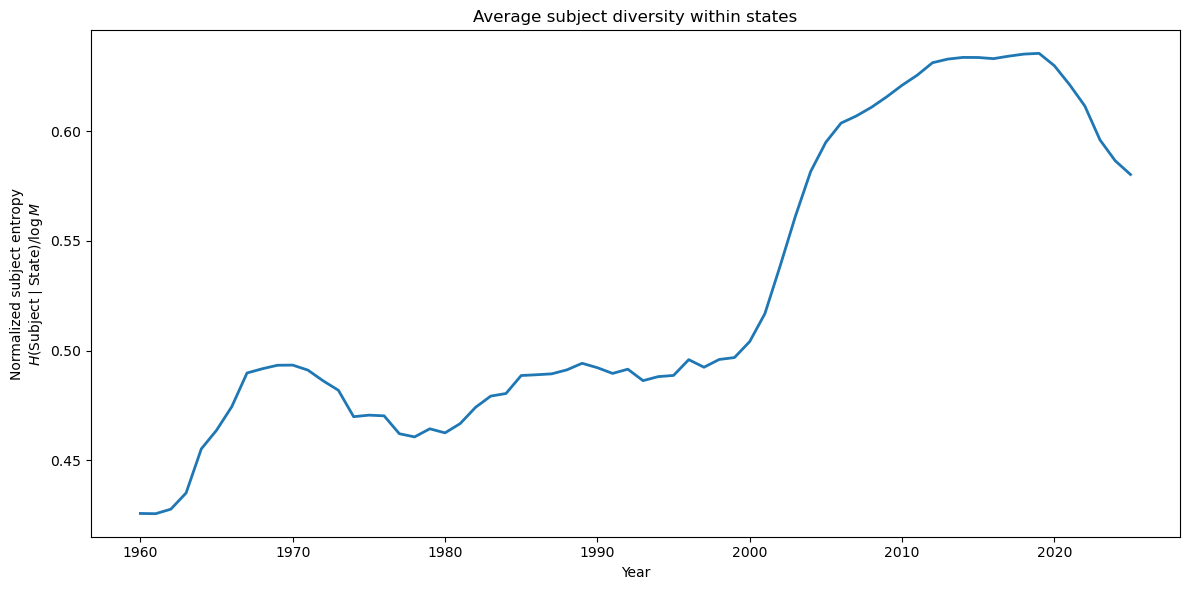

In [13]:
state_subject_summary = weighted_yearly_entropy(
    state_subject_entropy
)

state_subject_summary["smoothed_entropy"] = (
    state_subject_summary[
        "normalized_conditional_entropy"
    ]
    .rolling(
        5,
        center=True,
        min_periods=1,
    )
    .mean()
)

plt.figure(figsize=(12, 6))
plt.plot(
    state_subject_summary["year"],
    state_subject_summary["smoothed_entropy"],
    linewidth=2,
)
plt.xlabel("Year")
plt.ylabel(
    "Normalized subject entropy\n"
    "$H(\\mathrm{Subject}\\mid\\mathrm{State})/\\log M$"
)
plt.title(
    "Average subject diversity within states"
)
plt.tight_layout()
plt.show()

### 5.2 Annual entropy heatmap for all states

Cells are blank when a state has fewer than `MIN_STATE_YEAR_COUNT` dissertations in that year.

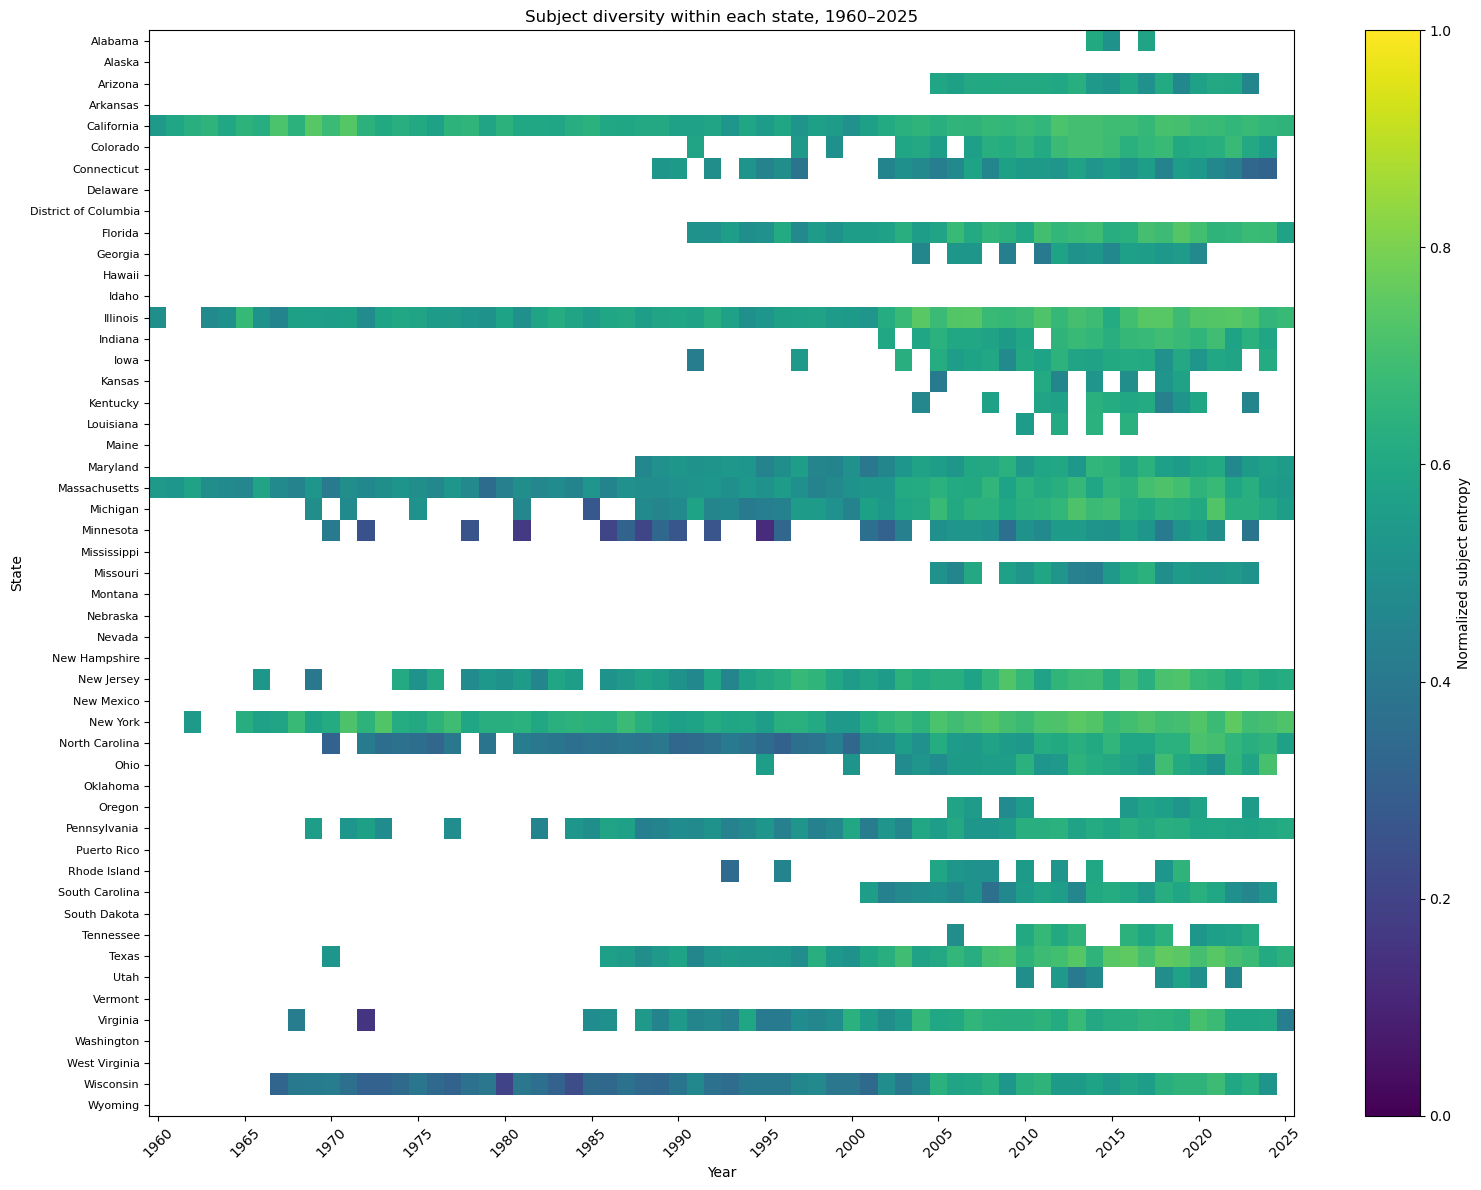

In [14]:
state_heatmap_data = (
    state_subject_entropy[
        state_subject_entropy["reliable"]
    ]
    .pivot(
        index="state",
        columns="year",
        values="normalized_entropy",
    )
    .reindex(
        index=sorted(
            state_subject_entropy["state"].unique()
        ),
        columns=YEARS,
    )
)

plt.figure(figsize=(16, 12))
image = plt.imshow(
    state_heatmap_data.to_numpy(dtype=float),
    aspect="auto",
    vmin=0,
    vmax=1,
    interpolation="nearest",
)

plt.colorbar(
    image,
    label="Normalized subject entropy",
)

plt.xticks(
    year_tick_positions,
    YEARS[year_tick_positions],
    rotation=45,
)
plt.yticks(
    np.arange(state_heatmap_data.shape[0]),
    state_heatmap_data.index,
    fontsize=8,
)

plt.xlabel("Year")
plt.ylabel("State")
plt.title(
    "Subject diversity within each state, "
    "1960–2025"
)
plt.tight_layout()
plt.show()

### 5.3 Recent state subject diversity

The following ranking pools data from 2015–2025. States with at least 100 dissertations in the period are retained.

In [15]:
recent_state_data = (
    nodes[
        nodes["year"].between(2015, 2025)
    ]
    .groupby(
        ["state", "subject_code"],
        as_index=False,
    )["num_dissertations"]
    .sum()
)

recent_state_data["period"] = "2015-2025"

recent_state_entropy = grouped_entropy(
    data=recent_state_data,
    group_columns=[
        "period",
        "state",
    ],
    category_column="subject_code",
    universe_size=NUMBER_OF_SUBJECTS,
)

recent_state_entropy = recent_state_entropy[
    recent_state_entropy["total_count"].ge(100)
].sort_values(
    "normalized_entropy",
    ascending=False,
)

display(
    recent_state_entropy[
        [
            "state",
            "normalized_entropy",
            "effective_number",
            "active_categories",
            "total_count",
        ]
    ].round(3)
)

,state,normalized_entropy,effective_number,active_categories,total_count
14,Indiana,0.788,26.202,39,330.0
43,Texas,0.772,24.515,52,1193.0
42,Tennessee,0.764,23.743,38,221.0
13,Illinois,0.764,23.727,50,1087.0
5,Colorado,0.754,22.756,37,333.0
32,New York,0.751,22.453,55,1643.0
9,Florida,0.744,21.785,54,897.0
34,Ohio,0.741,21.575,45,388.0
30,New Jersey,0.732,20.745,44,623.0
39,Rhode Island,0.723,20.012,33,169.0


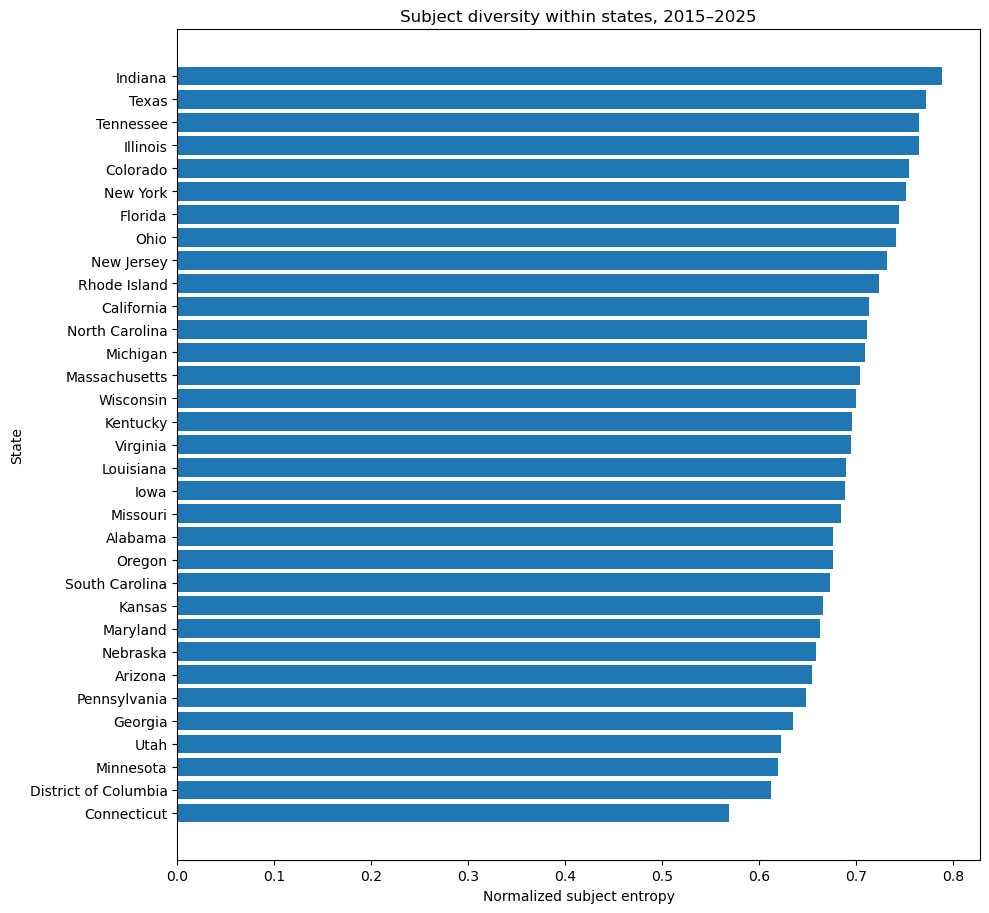

In [16]:
plot_data = recent_state_entropy.sort_values(
    "normalized_entropy"
)

plt.figure(
    figsize=(
        10,
        max(7, 0.28 * len(plot_data)),
    )
)
plt.barh(
    plot_data["state"],
    plot_data["normalized_entropy"],
)
plt.xlabel("Normalized subject entropy")
plt.ylabel("State")
plt.title(
    "Subject diversity within states, 2015–2025"
)
plt.tight_layout()
plt.show()

### 5.4 Long-run changes in state subject diversity

This comparison again uses pooled early and recent periods. States must have at least 100 dissertations in each period.

In [17]:
def pooled_state_subject_entropy(
    data,
    start_year,
    end_year,
):
    pooled = (
        data[
            data["year"].between(
                start_year,
                end_year,
            )
        ]
        .groupby(
            [
                "state",
                "subject_code",
            ],
            as_index=False,
        )["num_dissertations"]
        .sum()
    )

    pooled["period"] = f"{start_year}-{end_year}"

    return grouped_entropy(
        data=pooled,
        group_columns=[
            "period",
            "state",
        ],
        category_column="subject_code",
        universe_size=NUMBER_OF_SUBJECTS,
    )


state_entropy_early = pooled_state_subject_entropy(
    nodes,
    1960,
    1979,
).rename(
    columns={
        "normalized_entropy": "early_entropy",
        "total_count": "early_count",
    }
)

state_entropy_recent = pooled_state_subject_entropy(
    nodes,
    2005,
    2025,
).rename(
    columns={
        "normalized_entropy": "recent_entropy",
        "total_count": "recent_count",
    }
)

state_entropy_change = state_entropy_early[
    [
        "state",
        "early_entropy",
        "early_count",
    ]
].merge(
    state_entropy_recent[
        [
            "state",
            "recent_entropy",
            "recent_count",
        ]
    ],
    on="state",
    how="inner",
)

state_entropy_change = state_entropy_change[
    state_entropy_change["early_count"].ge(100)
    & state_entropy_change["recent_count"].ge(100)
].copy()

state_entropy_change["entropy_change"] = (
    state_entropy_change["recent_entropy"]
    - state_entropy_change["early_entropy"]
)

state_change_ranked = pd.concat(
    [
        state_entropy_change.nlargest(
            10,
            "entropy_change",
        ).assign(direction="More subject-diverse"),
        state_entropy_change.nsmallest(
            10,
            "entropy_change",
        ).assign(direction="More subject-concentrated"),
    ],
    ignore_index=True,
)

display(
    state_change_ranked[
        [
            "direction",
            "state",
            "early_entropy",
            "recent_entropy",
            "entropy_change",
            "early_count",
            "recent_count",
        ]
    ].round(3)
)

,direction,state,early_entropy,recent_entropy,entropy_change,early_count,recent_count
0,More subject-diverse,Rhode Island,0.347,0.707,0.360,138.0,399.0
1,More subject-diverse,Virginia,0.452,0.698,0.246,250.0,1819.0
2,More subject-diverse,Wisconsin,0.464,0.698,0.233,501.0,1031.0
3,More subject-diverse,Minnesota,0.409,0.612,0.204,289.0,763.0
4,More subject-diverse,North Carolina,0.477,0.678,0.202,353.0,1795.0
5,More subject-diverse,Massachusetts,0.559,0.686,0.127,1093.0,3208.0
6,More subject-diverse,Michigan,0.597,0.714,0.117,275.0,1877.0
7,More subject-diverse,Illinois,0.670,0.757,0.087,657.0,2534.0
8,More subject-diverse,Texas,0.676,0.752,0.075,195.0,2735.0
9,More subject-diverse,Ohio,0.659,0.713,0.054,121.0,830.0


## 6. State–subject association

The two conditional entropies can be connected through mutual information.

For each time window,

$$
I(\mathrm{State};\mathrm{Subject})
=
H(\mathrm{State})
+
H(\mathrm{Subject})
-
H(\mathrm{State},\mathrm{Subject}).
$$

The normalized mutual information used here is

$$
\mathrm{NMI}
=
\frac{
I(\mathrm{State};\mathrm{Subject})
}{
\sqrt{
H(\mathrm{State})
H(\mathrm{Subject})
}
}.
$$

Interpretation:

- NMI near 0: state and subject are close to independent;
- higher NMI: states have more distinct subject specializations.

Because contingency-table association measures can be noisy in sparse annual data, this section pools rolling five-year windows.

In [18]:
def shannon_entropy_from_counts(counts):
    counts = np.asarray(counts, dtype=float)
    counts = counts[counts > 0]

    probabilities = counts / counts.sum()

    return -np.sum(
        probabilities * np.log(probabilities)
    )


def state_subject_association(data):
    table = pd.pivot_table(
        data,
        index="state",
        columns="subject_code",
        values="num_dissertations",
        aggfunc="sum",
        fill_value=0,
    )

    matrix = table.to_numpy(dtype=float)

    state_entropy = shannon_entropy_from_counts(
        matrix.sum(axis=1)
    )
    subject_entropy = shannon_entropy_from_counts(
        matrix.sum(axis=0)
    )
    joint_entropy = shannon_entropy_from_counts(
        matrix.ravel()
    )

    mutual_information = (
        state_entropy
        + subject_entropy
        - joint_entropy
    )

    denominator = np.sqrt(
        state_entropy * subject_entropy
    )

    nmi = (
        mutual_information / denominator
        if denominator > 0
        else np.nan
    )

    return {
        "state_entropy": state_entropy,
        "subject_entropy": subject_entropy,
        "joint_entropy": joint_entropy,
        "mutual_information": mutual_information,
        "normalized_mutual_information": nmi,
        "total_count": matrix.sum(),
    }


association_records = []

for end_year in range(YEAR_START + 4, YEAR_END + 1):
    start_year = end_year - 4

    window_data = nodes[
        nodes["year"].between(
            start_year,
            end_year,
        )
    ]

    result = state_subject_association(window_data)

    association_records.append(
        {
            "window_start": start_year,
            "window_end": end_year,
            **result,
        }
    )

state_subject_nmi = pd.DataFrame(
    association_records
)

display(state_subject_nmi.tail())

,window_start,window_end,state_entropy,subject_entropy,joint_entropy,mutual_information,normalized_mutual_information,total_count
57,2017,2021,3.248786,3.157776,6.132871,0.273691,0.085449,10524.0
58,2018,2022,3.260196,3.161728,6.136195,0.285728,0.088996,9806.0
59,2019,2023,3.268213,3.146847,6.124210,0.290850,0.090694,9065.0
60,2020,2024,3.264857,3.142956,6.096834,0.310979,0.097080,8196.0
61,2021,2025,3.268052,3.152585,6.078740,0.341897,0.106517,6932.0


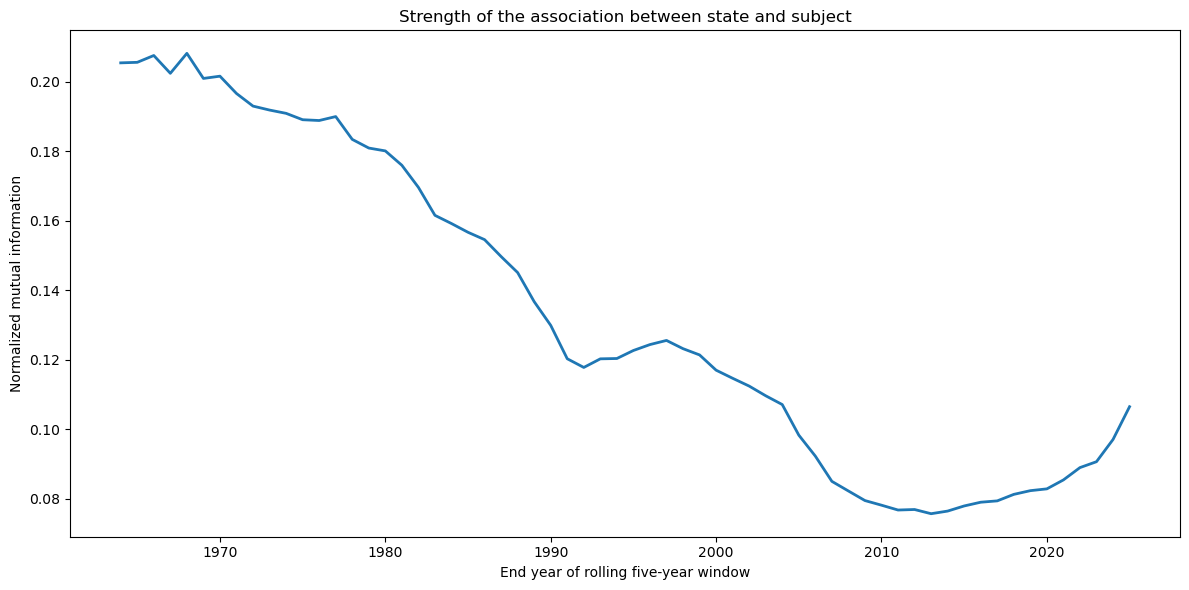

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(
    state_subject_nmi["window_end"],
    state_subject_nmi[
        "normalized_mutual_information"
    ],
    linewidth=2,
)
plt.xlabel("End year of rolling five-year window")
plt.ylabel("Normalized mutual information")
plt.title(
    "Strength of the association between state and subject"
)
plt.tight_layout()
plt.show()

## 7. Interpretation guide

### Geographic diversity of subjects

- Increasing $H(\mathrm{State}\mid\mathrm{Subject})$ means that subjects are becoming more geographically dispersed.
- Decreasing values mean that subjects are becoming more concentrated in particular states.
- Comparing pure and applied mathematics can show whether one basket has become more nationally distributed than the other.

### Subject diversity within states

- Increasing $H(\mathrm{Subject}\mid\mathrm{State})$ means that states are supporting a broader and more even mix of mathematics subjects.
- Decreasing values indicate increasing subject specialization within states.

### State–subject association

- Decreasing NMI means that knowing a dissertation's state gives less information about its subject; state subject profiles are becoming more similar.
- Increasing NMI means stronger geographic specialization.

### Important cautions

- Entropy is sensitive to sample size. The heatmaps therefore hide low-count state–year and subject–year observations.
- The 2025 data may be incomplete and should be treated as provisional.
- These results describe the geography recorded in MGP. They do not by themselves identify causal explanations for regional specialization or diversification.